# Clasificación Automática de Modulaciones (AMC)
## Comparación de arquitecturas: CNN, LSTM, GRU, TCN, CNN (A/φ), TCN (A/φ) y CNN_preproc

Este notebook **no entrena nada** — carga los pesos ya entrenados en `../cnn/`, `../lstm/`,
`../gru/`, `../tcn/`, `../cnn_ap/`, `../tcn_ap/` y `../cnn_preproc/` (cada uno entrenado una
sola vez en su propio notebook) y compara accuracy, accuracy vs SNR, curvas de pérdida y
complejidad (número de parámetros) entre ellos, con foco en el trade-off accuracy / liviandad
pensando en un futuro despliegue embebido.

`CNN (A/φ)` y `TCN (A/φ)` son las mismas arquitecturas que `CNN` y `TCN`, pero entrenadas con
la señal en representación Amplitud/Fase en vez de I/Q — al tener la misma arquitectura, la
diferencia de accuracy contra su contraparte I/Q aísla el efecto de la representación de
entrada. `CNN_preproc` (`ULCNN`) es una arquitectura nueva y bastante más chica (convolución
compleja + bloques depthwise/channel-attention + data augmentation por rotación) — el
candidato más prometedor para el objetivo de liviandad si su accuracy se sostiene.


## 1. Imports y configuración

In [1]:
import sys
sys.path.insert(0, "..")

import pickle

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from common.models import CNNBaseline, LSTMClassifier, GRUClassifier, TCN, ULCNN
from common.data import load_radioml_digital, split_dataset, to_amplitude_phase
from common.train import evaluate_by_snr, overall_accuracy, compute_cm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

print(f"Usando dispositivo: {DEVICE}")

Usando dispositivo: cpu


## 2. Carga del dataset (mismo split que en los notebooks de entrenamiento)

In [2]:
X, y, snrs, le = load_radioml_digital(seed=SEED)
N_CLASSES = len(le.classes_)

_, _, (X_test, y_test, snr_test) = split_dataset(X, y, snrs, seed=SEED)
X_test_ap = to_amplitude_phase(X_test)

# Cada modelo se evalúa con la representación con la que fue entrenado.
TEST_DATA = {"iq": X_test, "ap": X_test_ap}
print(f"Test: {X_test.shape}")

Test: (32000, 2, 128)


## 3. Carga de modelos ya entrenados

Cada modelo puede haber sido entrenado con una config de arquitectura distinta (`MODEL_KWARGS`
en su notebook). Esa config quedó guardada en su `history.pkl`, así que la leemos primero para
reconstruir cada modelo con los parámetros exactos antes de cargarle los pesos.

In [3]:
MODEL_SPECS = {
    # nombre: (clase, ruta de pesos, ruta de history, representación de entrada)
    "CNN": (CNNBaseline, "../cnn/cnn.pt", "../cnn/history.pkl", "iq"),
    "LSTM": (LSTMClassifier, "../lstm/lstm.pt", "../lstm/history.pkl", "iq"),
    "GRU": (GRUClassifier, "../gru/gru.pt", "../gru/history.pkl", "iq"),
    "TCN": (TCN, "../tcn/tcn.pt", "../tcn/history.pkl", "iq"),
    "CNN (A/\u03c6)": (CNNBaseline, "../cnn_ap/cnn_ap.pt", "../cnn_ap/history.pkl", "ap"),
    "TCN (A/\u03c6)": (TCN, "../tcn_ap/tcn_ap.pt", "../tcn_ap/history.pkl", "ap"),
    "CNN_preproc": (ULCNN, "../cnn_preproc/cnn_preproc.pt", "../cnn_preproc/history.pkl", "iq"),
}

MODELOS = {}
histories = {}
representations = {}
for nombre, (model_cls, weight_path, history_path, representation) in MODEL_SPECS.items():
    with open(history_path, "rb") as f:
        history = pickle.load(f)
    model_kwargs = history.get("model_kwargs", {})

    modelo = model_cls(n_classes=N_CLASSES, **model_kwargs)
    modelo.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    modelo.to(DEVICE)
    modelo.eval()

    MODELOS[nombre] = modelo
    histories[nombre] = history
    representations[nombre] = representation
    print(f"{nombre}: cargado con model_kwargs={model_kwargs}, representación={representation}")

CNN: cargado con model_kwargs={'channels': (64, 64), 'kernel_size': 3, 'fc_hidden': 128, 'dropout': 0.5}, representación=iq
LSTM: cargado con model_kwargs={'hidden_size': 128, 'num_layers': 2, 'fc_hidden': 64, 'dropout': 0.5}, representación=iq
GRU: cargado con model_kwargs={'hidden_size': 64, 'num_layers': 2, 'fc_hidden': 32, 'dropout': 0.4}, representación=iq
TCN: cargado con model_kwargs={'channels': 64, 'dilations': (1, 2, 4), 'dropout': 0.4}, representación=iq
CNN (A/φ): cargado con model_kwargs={'channels': (64, 64), 'kernel_size': 3, 'fc_hidden': 128, 'dropout': 0.5}, representación=ap
TCN (A/φ): cargado con model_kwargs={'channels': 64, 'dilations': (1, 2, 4, 8), 'dropout': 0.2}, representación=ap
CNN_preproc: cargado con model_kwargs={'n_cv': 16, 'kernel_size': 5, 'n_fmdr': 6, 'shuffle_groups': 2, 'attn_reduction': 2}, representación=iq


## 4. Comparación de accuracy y complejidad

In [4]:
print("=== Resumen trade-off accuracy / complejidad ===")
print(f'{"Modelo":12s} | {"Parámetros":>12s} | {"Accuracy global":>16s}')
print("-" * 49)
resumen = {}
for nombre, modelo in MODELOS.items():
    params = modelo.count_parameters()
    X_eval = TEST_DATA[representations[nombre]]
    acc = overall_accuracy(modelo, X_eval, y_test, DEVICE)
    resumen[nombre] = {"params": params, "acc": acc}
    print(f"{nombre:12s} | {params:12,d} | {acc:16.4f}")

=== Resumen trade-off accuracy / complejidad ===
Modelo       |   Parámetros |  Accuracy global
-------------------------------------------------
CNN          |    1,063,048 |           0.5134
LSTM         |      208,584 |           0.1792
GRU          |       40,424 |           0.4111
TCN          |       75,592 |           0.5755
CNN (A/φ)    |    1,063,048 |           0.5213
TCN (A/φ)    |      100,552 |           0.6533
CNN_preproc  |        9,364 |           0.6158


## 5. Gráficos comparativos

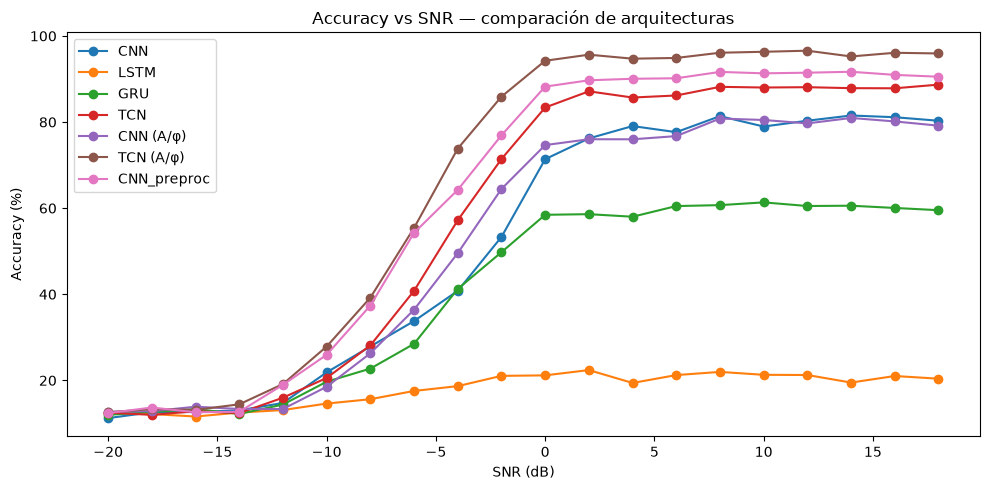

In [5]:
# Accuracy vs SNR — todos los modelos
plt.figure(figsize=(10, 5))
for nombre, modelo in MODELOS.items():
    X_eval = TEST_DATA[representations[nombre]]
    snr_acc = evaluate_by_snr(modelo, X_eval, y_test, snr_test, device=DEVICE)
    snr_levels = sorted(snr_acc.keys())
    plt.plot(snr_levels, [snr_acc[s] * 100 for s in snr_levels], marker="o", label=nombre)

plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs SNR — comparación de arquitecturas")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_vs_snr_comparacion.png", dpi=150)
plt.show()

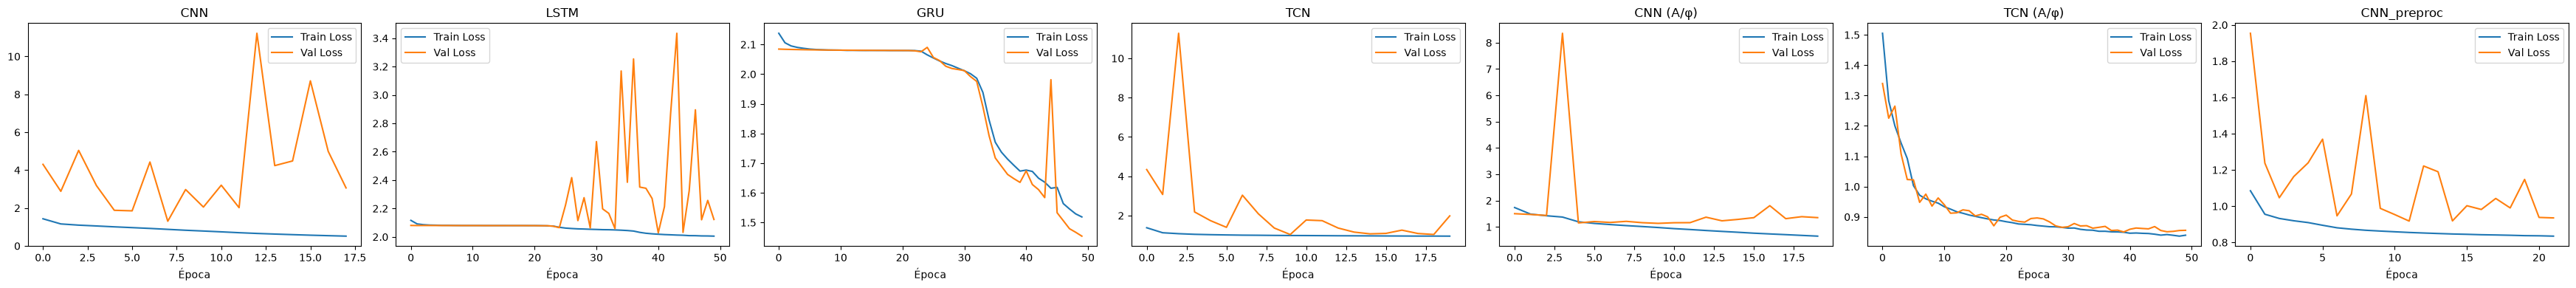

In [6]:
# Curvas de pérdida — todos los modelos
fig, axes = plt.subplots(1, len(MODELOS), figsize=(5 * len(MODELOS), 4))
for ax, nombre in zip(axes, MODELOS.keys()):
    history = histories[nombre]
    ax.plot(history["train_loss"], label="Train Loss")
    ax.plot(history["val_loss"], label="Val Loss")
    ax.set_title(nombre)
    ax.set_xlabel("Época")
    ax.legend()
plt.tight_layout()
plt.savefig("curvas_perdida.png", dpi=150)
plt.show()

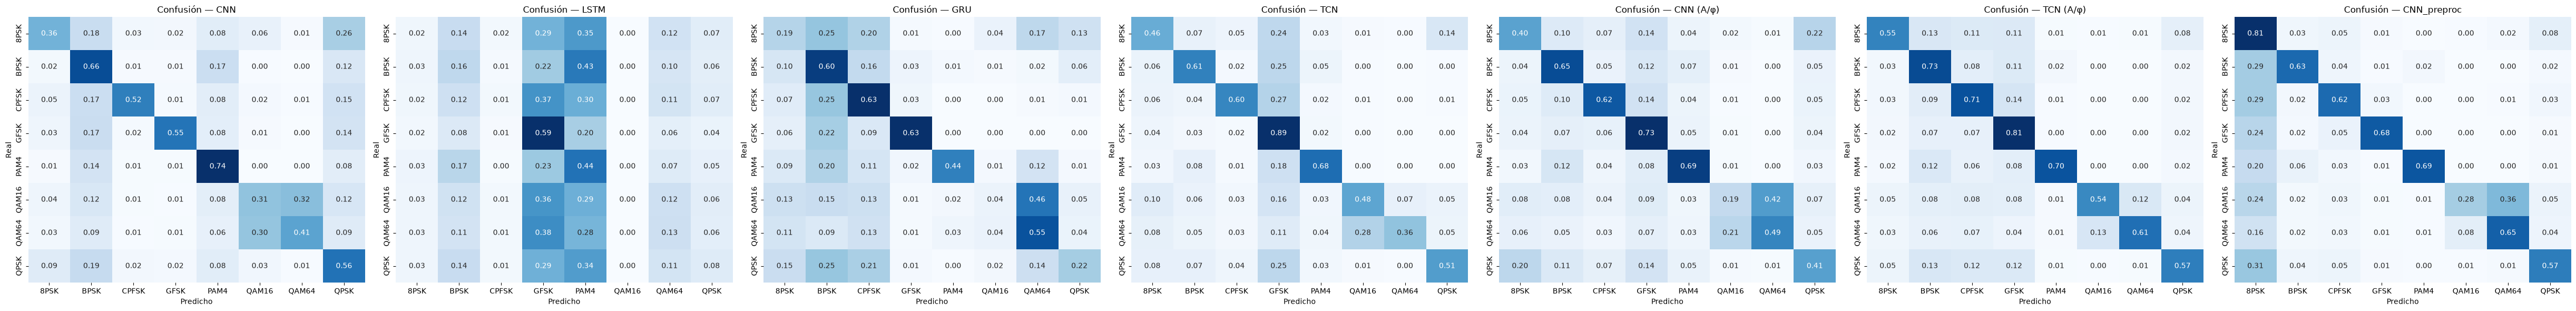

In [7]:
# Matrices de confusión — todos los modelos (todos los SNR)
fig, axes = plt.subplots(1, len(MODELOS), figsize=(7 * len(MODELOS), 6))
for ax, nombre in zip(axes, MODELOS.keys()):
    modelo = MODELOS[nombre]
    X_eval = TEST_DATA[representations[nombre]]
    cm = compute_cm(modelo, X_eval, y_test, device=DEVICE)
    sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Confusión — {nombre}")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()

### Matrices de confusión por rango de SNR

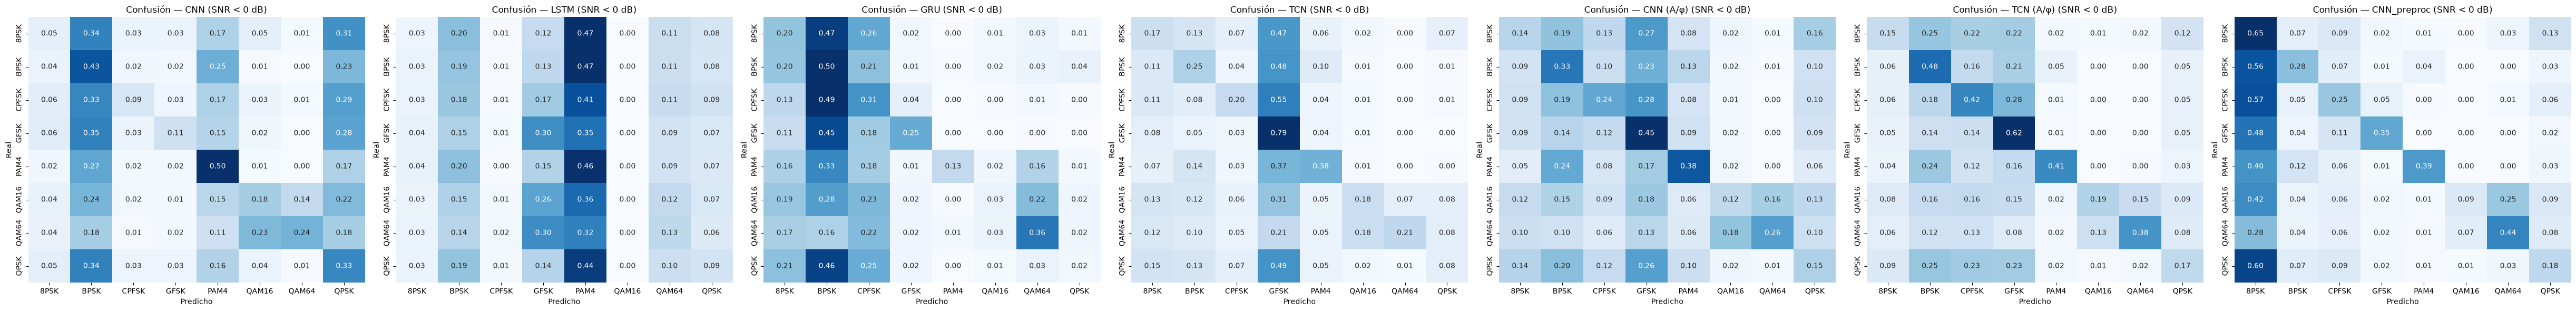

In [8]:
# Matrices de confusión — todos los modelos (SNR < 0 dB)
mask_low = snr_test < 0

fig, axes = plt.subplots(1, len(MODELOS), figsize=(7 * len(MODELOS), 6))
for ax, nombre in zip(axes, MODELOS.keys()):
    modelo = MODELOS[nombre]
    X_eval = TEST_DATA[representations[nombre]]
    cm = compute_cm(modelo, X_eval[mask_low], y_test[mask_low], device=DEVICE)
    sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Confusión — {nombre} (SNR < 0 dB)")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("confusion_matrices_snr_bajo.png", dpi=150)
plt.show()

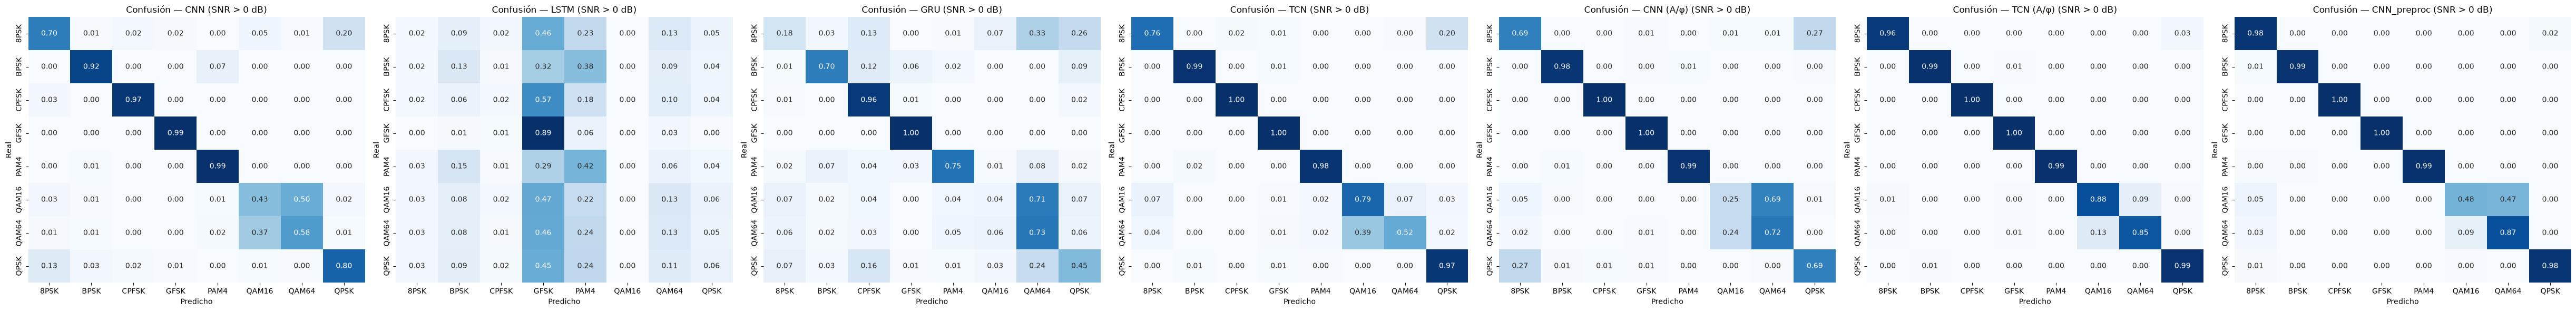

In [9]:
# Matrices de confusión — todos los modelos (SNR > 0 dB)
mask_high = snr_test > 0

fig, axes = plt.subplots(1, len(MODELOS), figsize=(7 * len(MODELOS), 6))
for ax, nombre in zip(axes, MODELOS.keys()):
    modelo = MODELOS[nombre]
    X_eval = TEST_DATA[representations[nombre]]
    cm = compute_cm(modelo, X_eval[mask_high], y_test[mask_high], device=DEVICE)
    sns.heatmap(cm, annot=True, fmt=".2f", xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", ax=ax, cbar=False)
    ax.set_title(f"Confusión — {nombre} (SNR > 0 dB)")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("confusion_matrices_snr_alto.png", dpi=150)
plt.show()

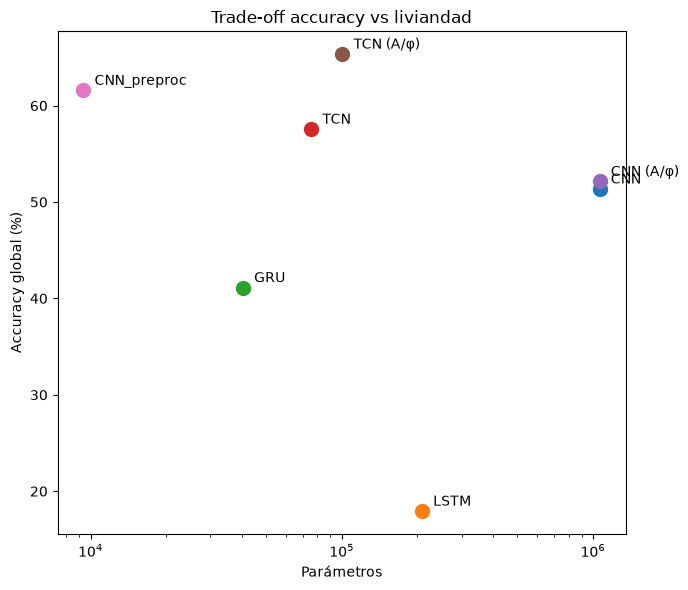

In [10]:
# Accuracy vs parámetros (trade-off liviandad / desempeño)
plt.figure(figsize=(7, 6))
for nombre, r in resumen.items():
    plt.scatter(r["params"], r["acc"] * 100, s=100)
    plt.annotate(nombre, (r["params"], r["acc"] * 100), textcoords="offset points", xytext=(8, 4))

plt.xlabel("Parámetros")
plt.ylabel("Accuracy global (%)")
plt.xscale("log")
plt.title("Trade-off accuracy vs liviandad")
plt.tight_layout()
plt.savefig("accuracy_vs_parametros.png", dpi=150)
plt.show()